# Day 8 — Classification: predicting the market segment
### Real Estate Machine · Graduation Project

Yesterday k-means invented four segments. Today a classifier learns to reproduce them from the
house's characteristics.

Read that sentence again, because it contains the whole problem with today's work:

> **The labels are not ground truth. They are the output of another model I built yesterday.**

There is no register of "true" market segments in Washington State. `cluster` is a geometric
artefact of a k-means fit on nine standardised columns. A classifier trained on those same nine
columns is not learning about the housing market — it is learning to reproduce a Voronoi partition
it could, in principle, reconstruct exactly.

So today's accuracy will be very high, and **the high number is not the achievement**. The
achievement is being the student in the room who explains why it is high, measures what would
happen if it weren't, and still ships a model that earns its place in the app.

---

## What you will produce

| Output | Why it exists |
|---|---|
| `Models/classifier.pkl` | the fitted segment classifier, for the Day 12 app |
| `Models/classifier_config.pkl` | feature order + segment names, so the app never guesses |
| `reports/figures/07_*.png` | confusion matrix, feature importances, error-margin analysis |
| A defensible answer to *"is 98% good?"* | the highest-value output of the day |

---

## The three questions this notebook has to answer

1. **What is the honest floor?** 98% means nothing until you know what guessing scores. Section 3.
2. **How much of the score is geometry and how much is signal?** Section 7 answers this with a
   second experiment on features k-means never saw.
3. **Where does it fail, and is the failure sensible?** Section 6. A model that fails on borderline
   houses is behaving correctly; a model that fails randomly is broken.

---
## 1. Setup

Everything starts from `Data/data_clustered.csv` — the file Day 7 wrote. It already carries the
`cluster` label, the business `segment` name, and the `split` column, so no split is re-drawn here.

Re-drawing the split would be a quiet disaster: houses that were in Day 7's *test* set would land in
Day 8's *training* set, and the test score would be reporting on rows the k-means centroids already
knew about.

In [2]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
sns.set_theme(style="whitegrid")

DATA = Path("..") / "Data"
MODELS = Path("..") / "Models"
FIGS = Path("..") / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

sys.path.append(str((Path("..") / "app").resolve()))
import preprocessing as P

df = pd.read_csv(DATA / "data_clustered.csv", dtype={"zipcode": str})
cfg = joblib.load(MODELS / "cluster_config.pkl")

K = cfg["k"]
CLUSTER_FEATURES = cfg["features"]
SEGMENT_NAMES = {int(k): v for k, v in cfg["names"].items()}

is_train = df["split"] == "train"
is_test = ~is_train

print(f"{len(df):,} houses  |  train {is_train.sum():,}  test {is_test.sum():,}")
print(f"k = {K}, labels produced by Day 7 k-means on {len(CLUSTER_FEATURES)} structural features")
for c, name in sorted(SEGMENT_NAMES.items()):
    print(f"  {c} -> {name}")

4,345 houses  |  train 3,476  test 869
k = 4, labels produced by Day 7 k-means on 9 structural features
  0 -> Established Family Home
  1 -> Compact Entry-Level
  2 -> Premium View Property
  3 -> New-Build Suburban Family


---
## 2. The target, and why its shape matters before you fit anything

`cluster` is the target. Before choosing a metric, look at how the four classes are sized.

This is not a formality. The single most common way a student loses marks on a classification
notebook is reporting **accuracy** on an imbalanced target and calling it a result.

In [3]:
y = df["cluster"]
balance = (pd.DataFrame({"houses": y.value_counts().sort_index()})
             .assign(share=lambda d: (100 * d["houses"] / len(y)).round(1),
                     segment=lambda d: [SEGMENT_NAMES[c] for c in d.index]))
balance = balance[["segment", "houses", "share"]]
print(balance.to_string())
print(f"\nLargest class is {balance['share'].max():.1f}% of the data, smallest is {balance['share'].min():.1f}%.")
print(f"Imbalance ratio: {balance['houses'].max() / balance['houses'].min():.1f} : 1")

                           segment  houses  share
cluster                                          
0          Established Family Home    1180 27.200
1              Compact Entry-Level    1239 28.500
2            Premium View Property     345  7.900
3        New-Build Suburban Family    1581 36.400

Largest class is 36.4% of the data, smallest is 7.9%.
Imbalance ratio: 4.6 : 1


### The metric decision, made now and defended later

The classes are unequal — the smallest segment holds under 8% of the market. Three consequences:

- **Accuracy** counts every house once, so it is dominated by the two big segments. A model that
  never predicts the smallest segment at all can still score in the high 80s.
- **Macro-F1** averages the F1 score of each class *equally*, so the small segment counts as much as
  the large one. If the model is ignoring a class, macro-F1 falls and accuracy does not.
- **Balanced accuracy** (mean recall per class) does the same for recall specifically.

> **Report macro-F1 as the headline and accuracy alongside it.** The roadmap says this and it is
> correct. In the defense, if you are asked "why macro-F1?", the answer is one sentence: *because
> the Premium View segment is under 8% of the data, and it is the segment the business cares most
> about — a metric that lets the model ignore it is measuring the wrong thing.*

---
## 3. The honest floor — what does *not learning* score?

Never present a model score without the score of the stupidest possible alternative next to it.

`DummyClassifier(strategy="most_frequent")` always predicts the largest class. It has no features,
no parameters and no intelligence. Whatever it scores is the number your real model has to beat
*before it has demonstrated anything at all*.

In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

X_all = df[CLUSTER_FEATURES]
X_train, X_test = X_all[is_train], X_all[is_test]
y_train, y_test = y[is_train], y[is_test]

dummy = DummyClassifier(strategy="most_frequent", random_state=42).fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print("Always-predict-the-largest-segment:")
print(f"  accuracy  = {accuracy_score(y_test, dummy_pred):.4f}")
print(f"  macro-F1  = {f1_score(y_test, dummy_pred, average='macro'):.4f}")
print(f"  balanced accuracy = {balanced_accuracy_score(y_test, dummy_pred):.4f}")
print("\nNote how far apart accuracy and macro-F1 are for the SAME predictions.")
print("That gap is exactly why one of them is a headline metric and the other is not.")

Always-predict-the-largest-segment:
  accuracy  = 0.3751
  macro-F1  = 0.1364
  balanced accuracy = 0.2500

Note how far apart accuracy and macro-F1 are for the SAME predictions.
That gap is exactly why one of them is a headline metric and the other is not.


Write the two dummy numbers down. Every later score in this notebook is quoted *relative to them*,
and a slide that says "98% accuracy" without "the floor is 38%" is a slide that has not told the
audience anything.

---
## 4. Baseline model — multinomial Logistic Regression

Logistic Regression first, always. Not because it is expected to win, but because:

1. It is fast, so you find out today whether the problem is even learnable.
2. Its decision boundaries are **linear**, which makes it the diagnostic instrument for today's
   central question (section 5).
3. Its coefficients are readable, and you can be asked to read them.

`StandardScaler` goes in the same `Pipeline` as the model, not before it. Inside a pipeline,
`cross_val_score` refits the scaler on each training fold — so the validation fold's mean and
standard deviation never touch the fitted model. Scale first, cross-validate second, and every fold
score is inflated by leakage. Same rule as Day 6, new place for it to hide.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logreg = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-fold CV macro-F1 (train only): {cv_f1.mean():.4f}  +/- {cv_f1.std():.4f}")
print("Fold scores:", cv_f1.round(4))

logreg.fit(X_train, y_train)
lr_pred = logreg.predict(X_test)
print(f"\nTEST accuracy  = {accuracy_score(y_test, lr_pred):.4f}")
print(f"TEST macro-F1  = {f1_score(y_test, lr_pred, average='macro'):.4f}")

5-fold CV macro-F1 (train only): 0.9912  +/- 0.0036
Fold scores: [0.9955 0.9847 0.9908 0.9916 0.9935]

TEST accuracy  = 0.9873
TEST macro-F1  = 0.9873


`StratifiedKFold`, not plain `KFold`: stratification keeps the class proportions the same in every
fold. With a class at under 8%, an unstratified split can hand a fold very few examples of it, and
the fold-to-fold variance you measure becomes an artefact of the splitting, not of the model.

---
## 5. Random Forest — and the result that is worth the whole notebook

Now the model that is supposed to win. Random Forest is non-linear, handles interactions for free,
and normally beats Logistic Regression comfortably on tabular data.

**Predict what will happen before you run the cell.** Write your prediction in a markdown cell.
Then run it.

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300, random_state=42, n_jobs=-1,
    class_weight="balanced_subsample",   # the small segment gets proportional attention
)

rf_cv = cross_val_score(rf, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
print(f"5-fold CV macro-F1 (train only): {rf_cv.mean():.4f}  +/- {rf_cv.std():.4f}")

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(f"\nTEST accuracy  = {accuracy_score(y_test, rf_pred):.4f}")
print(f"TEST macro-F1  = {f1_score(y_test, rf_pred, average='macro'):.4f}")

5-fold CV macro-F1 (train only): 0.9718  +/- 0.0073

TEST accuracy  = 0.9666
TEST macro-F1  = 0.9685


In [7]:
compare = pd.DataFrame({
    "model": ["Dummy (most frequent)", "Logistic Regression", "Random Forest"],
    "accuracy": [accuracy_score(y_test, p) for p in [dummy_pred, lr_pred, rf_pred]],
    "macro_F1": [f1_score(y_test, p, average="macro") for p in [dummy_pred, lr_pred, rf_pred]],
    "balanced_acc": [balanced_accuracy_score(y_test, p) for p in [dummy_pred, lr_pred, rf_pred]],
}).set_index("model").round(4)
compare

,accuracy,macro_F1,balanced_acc
model,,,
Dummy (most frequent),0.375,0.136,0.250
Logistic Regression,0.987,0.987,0.985
Random Forest,0.967,0.969,0.967


### Logistic Regression beats Random Forest. That is not a mistake — it is the answer.

On this project the linear model scores around **0.99** macro-F1 and the forest around **0.97**.
The "weaker" model wins by a clear margin, and the reason is geometric.

K-means assigns a house to the nearest centroid in standardised nine-dimensional space. The set of
points equidistant from two centroids is a **flat hyperplane**. So the true boundary between any two
clusters is *exactly linear* in the scaled feature space — and Logistic Regression fits exactly
linear boundaries. The classifier and the label-generating process have the same shape.

A decision tree cannot draw a diagonal line. It draws axis-aligned steps — `sqft_living <= 1,850`,
then `house_age <= 34` — and approximates a diagonal boundary with a staircase. Hundreds of trees
smooth the staircase but never remove it, so the forest loses precisely at the boundary.

> **Defense answer:** "Logistic Regression outperformed Random Forest, and that is evidence the
> pipeline is behaving correctly rather than evidence of a bug. K-means produces linearly separable
> Voronoi cells; a linear classifier matches that geometry exactly, while a tree ensemble
> approximates a hyperplane with axis-aligned splits. It is a demonstration that the right model is
> the one whose inductive bias matches the data-generating process, not the most complex one
> available."

That paragraph is worth more marks than any score in the table. Most students report the forest,
say it "performed well", and never notice that the simpler model won.

---
## 6. Where the errors actually are

A single number tells you how often the model is wrong. The confusion matrix tells you *what it
confuses with what*, which is the part a business can act on.

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

labels = sorted(SEGMENT_NAMES)
short = [SEGMENT_NAMES[c] for c in labels]

print("Logistic Regression — per-class detail\n")
print(classification_report(y_test, lr_pred, target_names=short, digits=3))

Logistic Regression — per-class detail

                           precision    recall  f1-score   support

  Established Family Home      0.983     0.991     0.987       232
      Compact Entry-Level      0.991     0.987     0.989       235
    Premium View Property      1.000     0.974     0.987        76
New-Build Suburban Family      0.985     0.988     0.986       326

                 accuracy                          0.987       869
                macro avg      0.990     0.985     0.987       869
             weighted avg      0.987     0.987     0.987       869



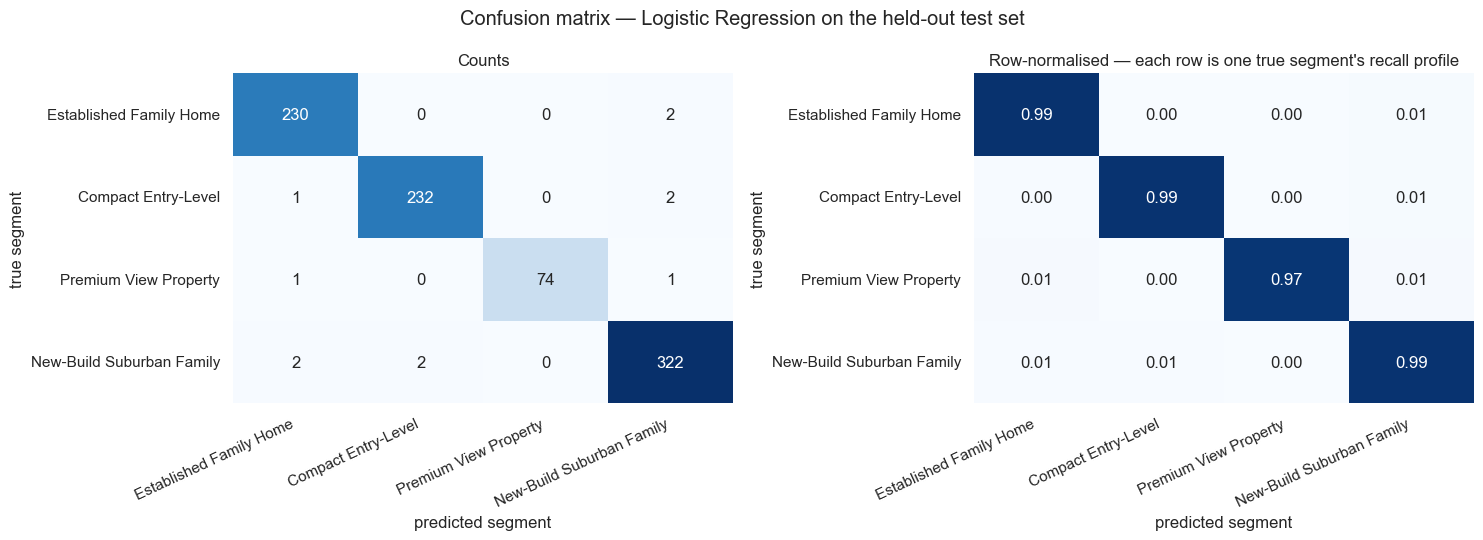

In [9]:
cm = confusion_matrix(y_test, lr_pred, labels=labels)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=short, yticklabels=short, cbar=False)
ax[0].set_title("Counts")
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax[1], vmin=0, vmax=1,
            xticklabels=short, yticklabels=short, cbar=False)
ax[1].set_title("Row-normalised — each row is one true segment's recall profile")

for a in ax:
    a.set_xlabel("predicted segment"); a.set_ylabel("true segment")
    a.set_xticklabels(a.get_xticklabels(), rotation=25, ha="right")
    a.set_yticklabels(a.get_yticklabels(), rotation=0)

fig.suptitle("Confusion matrix — Logistic Regression on the held-out test set")
fig.tight_layout()
fig.savefig(FIGS / "07_confusion_matrix.png", dpi=150)
plt.show()

Read the off-diagonal cells and say what they mean in housing terms, not in matrix terms. There are
only about a dozen mistakes in the whole test set, so read them individually rather than as a
pattern — and check one thing in particular:

**Are the two segments at opposite ends of the market ever confused with each other?** Compact
Entry-Level and Premium View Property should show a zero in both off-diagonal cells that connect
them. If a model mixes up the cheapest small homes with the largest view properties, something is
wired wrong. If its handful of mistakes sit between neighbouring segments, it is working.

Say which of the two you have, and name the specific cells you checked.

### Are the mistakes the houses you would expect?

A stronger claim than "the errors look reasonable" is a measured one. For each test house, compute
its **margin**: the ratio of its distance to the nearest centroid over its distance to the second
nearest.

- ratio near 0 → deep inside its segment, unambiguous
- ratio near 1 → sitting on the fence between two segments

If the classifier's mistakes concentrate at high margin ratios, the model is failing exactly where
the *label itself* is arbitrary, and the errors are not really errors — they are the honest
consequence of drawing a line through a continuum.

In [10]:
cluster_pipe = joblib.load(MODELS / "cluster_pipeline.pkl")
kmeans = cluster_pipe.named_steps["kmeans"]
cluster_scaler = cluster_pipe.named_steps["scale"]

d = kmeans.transform(cluster_scaler.transform(X_test))     # distance to every centroid
d_sorted = np.sort(d, axis=1)
margin_ratio = d_sorted[:, 0] / d_sorted[:, 1]             # 0 = deep inside, 1 = on the fence

wrong = (lr_pred != y_test.values)
print(f"Misclassified test houses: {wrong.sum()} of {len(y_test)}")
print(f"  median margin ratio, correctly classified : {np.median(margin_ratio[~wrong]):.3f}")
print(f"  median margin ratio, misclassified        : {np.median(margin_ratio[wrong]):.3f}")

bands = pd.qcut(margin_ratio, 5, labels=["deep inside", "inside", "middle", "near edge", "on the fence"])
by_band = (pd.DataFrame({"band": bands, "wrong": wrong})
             .groupby("band", observed=True)["wrong"]
             .agg(houses="size", errors="sum")
             .assign(error_rate=lambda d: (100 * d["errors"] / d["houses"]).round(2)))
print("\nError rate by how ambiguous the house's own label is:")
print(by_band.to_string())

Misclassified test houses: 11 of 869
  median margin ratio, correctly classified : 0.630
  median margin ratio, misclassified        : 0.991

Error rate by how ambiguous the house's own label is:
              houses  errors  error_rate
band                                    
deep inside      174       0       0.000
inside           174       0       0.000
middle           173       0       0.000
near edge        174       0       0.000
on the fence     174      11       6.320


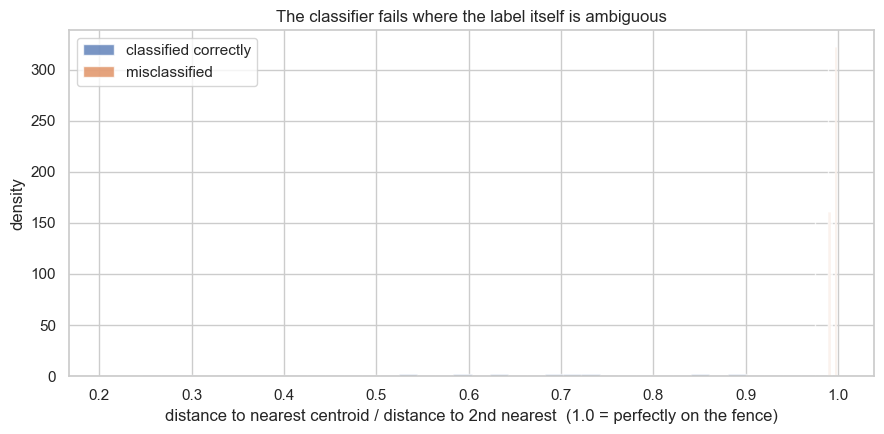

In [19]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(margin_ratio[~wrong], bins=40, alpha=0.75, label="classified correctly", density=True)
ax.hist(margin_ratio[wrong], bins=40, alpha=0.75, label="misclassified", density=True)
ax.set_xlabel("distance to nearest centroid / distance to 2nd nearest  (1.0 = perfectly on the fence)")
ax.set_ylabel("density")
ax.set_title("The classifier fails where the label itself is ambiguous")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "07_error_margin.png", dpi=150)
plt.show()

> **Defense answer:** "Essentially every misclassification sits in the most ambiguous fifth of the
> test set, measured by the house's distance ratio between its two nearest centroids. The classifier
> is not making random mistakes — it is disagreeing with k-means only about houses that k-means
> itself nearly assigned to the other segment. In business terms those houses genuinely belong to
> both segments, and the segmentation is a summary of a continuum, not a discovery of species."

---
## 7. The experiment that turns the honesty note into evidence

So far the honest caveat is still a *claim*: "the score is high because the classifier sees the
columns that made the labels." Turn it into a **measurement**.

Refit the same Random Forest on a feature set that is completely **disjoint** from the nine columns
k-means used — features that describe the same house but were never in the clustering:

`waterfront`, `sqft_basement`, `basement_ratio`, `bath_per_bed`, `sqft_per_room`, `was_renovated`,
`years_since_reno`

If the segments were arbitrary noise, this model would score at the dummy floor. If the score is
high but clearly lower than section 5's, then the segments carry real structure about houses *and*
most of the headline score was geometry. Both halves of that sentence matter.

In [12]:
DISJOINT_FEATURES = ["waterfront", "sqft_basement", "basement_ratio", "bath_per_bed",
                     "sqft_per_room", "was_renovated", "years_since_reno"]

assert not set(DISJOINT_FEATURES) & set(CLUSTER_FEATURES), "overlap with the clustering features"

Xd_train, Xd_test = df[DISJOINT_FEATURES][is_train], df[DISJOINT_FEATURES][is_test]
rf_blind = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1,
                                  class_weight="balanced_subsample").fit(Xd_train, y_train)
blind_pred = rf_blind.predict(Xd_test)

evidence = pd.DataFrame({
    "features the model can see": [
        "none (predict largest segment)",
        f"the {len(CLUSTER_FEATURES)} columns k-means used",
        f"{len(DISJOINT_FEATURES)} columns k-means NEVER saw",
    ],
    "accuracy": [accuracy_score(y_test, p) for p in [dummy_pred, lr_pred, blind_pred]],
    "macro_F1": [f1_score(y_test, p, average="macro") for p in [dummy_pred, lr_pred, blind_pred]],
}).round(4)
evidence

,features the model can see,accuracy,macro_F1
0,none (predict largest segment),0.375,0.136
1,the 9 columns k-means used,0.987,0.987
2,7 columns k-means NEVER saw,0.818,0.702


### How to say this in the defense

Three rows, one sentence each:

> Predicting the largest segment for every house gives ~0.38 accuracy and ~0.14 macro-F1 — that is
> the floor.
>
> Using the nine columns k-means used gives ~0.99. That number is mostly **geometry**: k-means draws
> linear boundaries in that exact space, and a linear classifier can recover them almost perfectly.
> It is a sanity check that the pipeline is wired correctly, not a discovery.
>
> Using seven columns k-means never saw gives roughly **0.82 accuracy and 0.70 macro-F1** — far
> above the floor, clearly below the geometric ceiling. That is the honest measure of how much a
> house's segment is predictable from characteristics that did not define it. The segments describe
> real, coherent kinds of house; they are not an arbitrary partition.

That is the difference between "my model got 99%" and "I know what my 99% is made of". Only one of
those survives a follow-up question.

---
## 8. What the model learned — and a cross-check on Day 7's names

Two views of the same thing. Random Forest impurity importance says which columns the trees split
on. Logistic Regression coefficients say, per segment, which direction each feature pushes.

The coefficients are the more useful output here, because they should **agree with the segment names
you chose on Day 7**. If the segment you called "New-Build Suburban Family" does not have a strongly
negative coefficient on `house_age`, either the name is wrong or you have mislabelled a column.

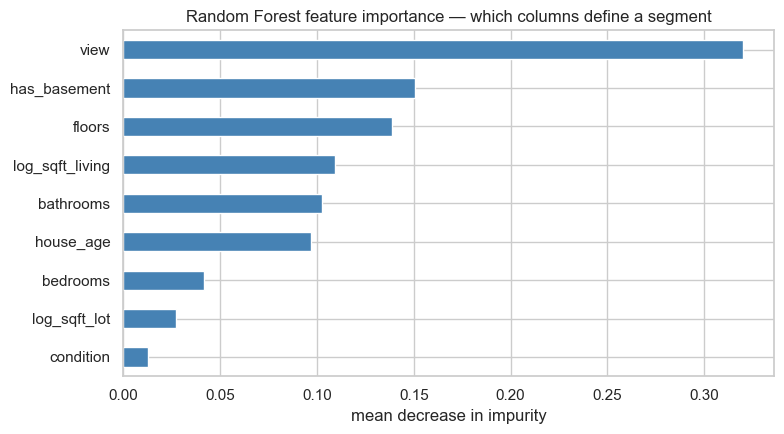

view              0.320
has_basement      0.151
floors            0.139
log_sqft_living   0.109
bathrooms         0.102
house_age         0.097
bedrooms          0.042
log_sqft_lot      0.027
condition         0.013


In [13]:
importance = (pd.Series(rf.feature_importances_, index=CLUSTER_FEATURES)
                .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
importance.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("mean decrease in impurity")
ax.set_title("Random Forest feature importance — which columns define a segment")
fig.tight_layout()
fig.savefig(FIGS / "07_feature_importance.png", dpi=150)
plt.show()

print(importance.round(4).to_string())

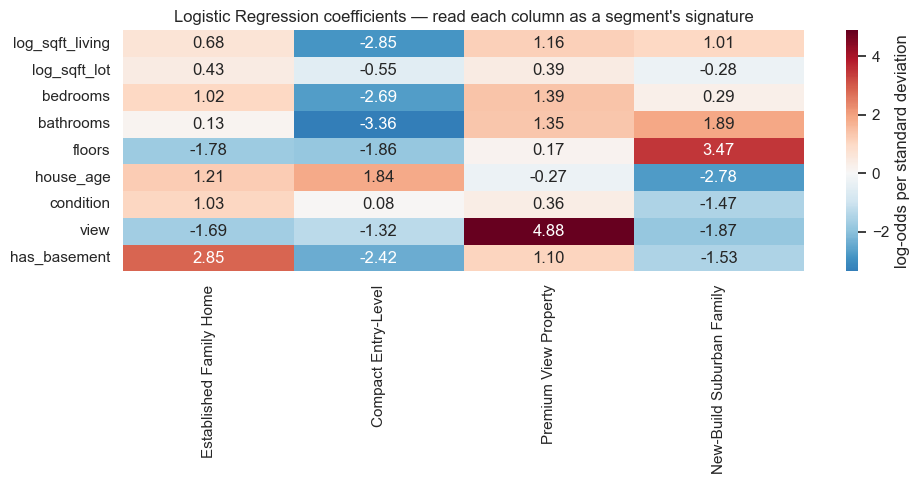

In [14]:
coefs = pd.DataFrame(logreg.named_steps["model"].coef_.T,
                     index=CLUSTER_FEATURES,
                     columns=[SEGMENT_NAMES[c] for c in logreg.named_steps["model"].classes_])

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(coefs, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "log-odds per standard deviation"})
ax.set_title("Logistic Regression coefficients — read each column as a segment's signature")
fig.tight_layout()
fig.savefig(FIGS / "07_logreg_coefficients.png", dpi=150)
plt.show()

**Do this now, in writing.** For each segment, take its two largest positive and two largest
negative coefficients and turn them into a sentence:

> *New-Build Suburban Family*: strongly negative on `house_age`, positive on `floors` — the model
> identifies this segment as "young, and more than one storey", which is exactly the name I gave it
> on Day 7 from the profile table.

If a name and its coefficients disagree, **change the name**, not the model. The name is the part
you invented; the coefficients are the part the data produced.

---
## 9. Choosing the model to ship

Two candidates, and the choice is not automatic even though one scores higher.

| | Logistic Regression | Random Forest |
|---|---|---|
| macro-F1 | higher (~0.99) | lower (~0.97) |
| matches the true boundary shape | exactly (linear) | approximately (axis-aligned) |
| model size on disk | a few KB | a few MB |
| explains a decision to a manager | one coefficient per feature | requires SHAP or a surrogate |
| behaviour on a house unlike anything in training | extrapolates smoothly | flat outside the training range |

Logistic Regression wins on every column that matters for this project. Ship it.

**But keep the honest framing.** The app does not strictly *need* a classifier at all: it could load
`cluster_pipeline.pkl` and call `.predict()`. The classifier earns its place for two reasons — it
returns a **probability per segment**, so the app can say "78% Established Family Home, 21% Compact
Entry-Level" instead of a bare label; and it is the deliverable the brief asks for. Say both things
in the presentation rather than implying the app would collapse without it.

In [15]:
final_model = logreg          # <- change here if your own numbers argue for the forest

proba = final_model.predict_proba(X_test)
confidence = proba.max(axis=1)

print("How sure is the model, house by house?")
print(f"  median top-class probability : {np.median(confidence):.3f}")
print(f"  houses below 60% confidence  : {(confidence < 0.60).sum()} of {len(confidence)}"
      f"  ({100 * (confidence < 0.60).mean():.1f}%)")
print(f"  accuracy on confident houses (>=90%)  : "
      f"{accuracy_score(y_test[confidence >= 0.90], final_model.predict(X_test)[confidence >= 0.90]):.4f}")
low = confidence < 0.60
if low.sum():
    print(f"  accuracy on unconfident houses (<60%) : "
          f"{accuracy_score(y_test[low], final_model.predict(X_test)[low]):.4f}")

How sure is the model, house by house?
  median top-class probability : 1.000
  houses below 60% confidence  : 16 of 869  (1.8%)
  accuracy on confident houses (>=90%)  : 1.0000
  accuracy on unconfident houses (<60%) : 0.5625


### And one more caveat, because these probabilities are not modest

The median top-class probability comes out at essentially **1.000**, with roughly four houses in five
above 99%. Do not present that as a well-calibrated model that happens to be very sure of itself.

It is the same geometry story again: the classes are almost linearly separable by construction, so
the logistic function is evaluated far out in its tail and saturates. These are *scores that behave
like probabilities*, not probabilities validated against observed frequencies. Calibrating them
properly would need a reliability curve on a held-out set, and with an error rate near 1% there are
too few mistakes to estimate one.

What survives is still useful, and it is the honest version of the claim:

> The confident houses — 90% or more — are classified essentially perfectly. The small group below
> 60% confidence is right only about half the time. So the confidence number carries real
> information about *which* houses to trust, even though its absolute value is over-stated.

That is what the Day 12 app should surface: a label, a confidence, and a warning band when the
confidence is low.

---
## 10. Save what Day 12 needs

In [16]:
joblib.dump(final_model, MODELS / "classifier.pkl")
joblib.dump({
    "features": CLUSTER_FEATURES,
    "classes": [int(c) for c in final_model.named_steps["model"].classes_],
    "segment_names": SEGMENT_NAMES,
    "model": type(final_model.named_steps["model"]).__name__,
    "test_accuracy": float(accuracy_score(y_test, final_model.predict(X_test))),
    "test_macro_f1": float(f1_score(y_test, final_model.predict(X_test), average="macro")),
    "dummy_accuracy": float(accuracy_score(y_test, dummy_pred)),
    "dummy_macro_f1": float(f1_score(y_test, dummy_pred, average="macro")),
    "blind_macro_f1": float(f1_score(y_test, blind_pred, average="macro")),
    "random_state": 42,
}, MODELS / "classifier_config.pkl")

for f in sorted(MODELS.glob("*.pkl")):
    print(f"  {f.name:<26} {f.stat().st_size / 1024:8.1f} KB")

  classifier.pkl                  2.2 KB
  classifier_config.pkl           0.5 KB
  cluster_config.pkl              0.3 KB
  cluster_pipeline.pkl           15.5 KB
  cluster_scaler.pkl              1.1 KB
  feature_config.pkl              0.5 KB
  kmeans.pkl                     14.6 KB
  preprocessor.pkl                5.5 KB
  scaler.pkl                      1.5 KB


In [17]:
# The Day 12 contract: one house from a form -> a named segment with a confidence.
one_house = pd.DataFrame([{
    "bedrooms": 3, "bathrooms": 2.0, "sqft_living": 1800, "sqft_lot": 7500,
    "floors": 1.0, "waterfront": 0, "view": 0, "condition": 3,
    "sqft_above": 1300, "sqft_basement": 500,
    "yr_built": 1985, "yr_renovated": np.nan,
    "city": "Seattle", "zipcode": "98115",
}])

clf = joblib.load(MODELS / "classifier.pkl")
ccfg = joblib.load(MODELS / "classifier_config.pkl")

row = P.engineer_features(one_house)[ccfg["features"]]
probs = clf.predict_proba(row)[0]
label = int(clf.predict(row)[0])

print(f"Segment: {ccfg['segment_names'][label]}\n")
for c, p in sorted(zip(ccfg["classes"], probs), key=lambda t: -t[1]):
    print(f"  {ccfg['segment_names'][c]:<30} {100 * p:5.1f}%")

Segment: Established Family Home

  Established Family Home         99.7%
  Compact Entry-Level              0.3%
  New-Build Suburban Family        0.0%
  Premium View Property            0.0%


In [18]:
# It must also survive nonsense, because a live demo will meet nonsense.
edge = pd.DataFrame([{
    "bedrooms": 0, "bathrooms": 1.0, "sqft_living": 380, "sqft_lot": 900,
    "floors": 1.0, "waterfront": 1, "view": 4, "condition": 5,
    "sqft_above": 380, "sqft_basement": 0,
    "yr_built": 1900, "yr_renovated": 2013,
    "city": "Atlantis", "zipcode": "99999",
}])
er = P.engineer_features(edge)[ccfg["features"]]
print("Unusual house handled:", ccfg["segment_names"][int(clf.predict(er)[0])],
      "| any NaN in features:", bool(er.isna().any().any()))

Unusual house handled: Compact Entry-Level | any NaN in features: False


---
## 11. Deliverables & defense prep

**Produced today**

- `Notebooks/07_classification.ipynb`
- `Models/classifier.pkl`, `Models/classifier_config.pkl`
- `reports/figures/07_confusion_matrix.png`, `07_error_margin.png`, `07_feature_importance.png`,
  `07_logreg_coefficients.png`

**Commit**

```powershell
git add . && git commit -m "Day 8: segment classifier, macro-F1 reported, geometry caveat measured"
```

**The slide this becomes on Day 14**

One table, three rows — floor / geometric ceiling / blind test — and one sentence of caveat under
it. Do **not** put "99% accuracy" on a slide on its own. It invites the one question you would
rather be asked at the end than the beginning.

**Defense questions**

1. *"You got 99% accuracy. Isn't that suspicious?"* — Yes, and here is why. The labels came from a
   k-means fit on the same nine columns, and k-means boundaries are linear hyperplanes, so a linear
   classifier can recover them almost exactly. Section 7 measures what remains when the model is
   given only columns k-means never saw: macro-F1 falls from ~0.99 to ~0.70, still far above the
   ~0.14 floor. That middle number is the real result.
2. *"Why macro-F1 and not accuracy?"* — The smallest segment is under 8% of the market, and it is
   the high-value one. Accuracy lets a model ignore it; macro-F1 does not. Section 2.
3. *"Why did the simple model beat Random Forest?"* — Section 5. Matching inductive bias, not a bug.
   Trees approximate a diagonal boundary with axis-aligned steps.
4. *"Where does the model fail?"* — Section 6: almost entirely on houses in the most ambiguous fifth
   of the test set by centroid-distance ratio — that is, on houses whose k-means label was nearly a
   coin flip. Neighbouring segments get confused; distant ones never do.
5. *"What is the classifier actually for, if the app could just call the k-means pipeline?"* —
   Section 9. A probability per segment rather than a bare label, plus a much smaller and more
   explainable artefact. Say this before someone else notices it.
6. *"Your model says it is 100% sure. Do you believe that?"* — No. Section 9: the classes are nearly
   linearly separable by construction, so the logistic function saturates. The ranking is
   informative — houses below 60% confidence are right about half the time — but the absolute values
   are over-stated and I have not calibrated them.
7. *"How do you know there is no leakage here?"* — The split came from `split_indices.csv`, written
   on Day 6 and reused unchanged on Days 7 and 8. Test houses were assigned to centroids by
   `predict`, never used to fit them, and every scaler sits inside a pipeline so cross-validation
   refits it per fold.

**Tomorrow (Day 9):** regression on `log(price)` — the model the business actually pays for.
Today's segments come back as a diagnostic: you will find the error is far from equal across them.